**Dataset Extraction**

In [1]:
!unzip -q final_canis_dataset.zip

**Setup & Imports**

In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import random
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# Paths
DATA_DIR     = "final_canis_dataset"
HISTORY_FILE = "data_scientist_output.json"
CLASS_NAMES  = ["arctic_wolf", "dingo", "domestic_dog"]
COLORS       = ["#E63946", "#457B9D", "#2A9D8F"]   # one colour per model
MODEL_NAMES  = ["ResNet50", "DenseNet121", "MobileNetV3"]

# Load training history
with open(HISTORY_FILE, "r") as f:
    experiment = json.load(f)

history      = experiment["metrics_history"]
train_times  = experiment["training_times_seconds"]

print("History loaded for models:", list(history.keys()))
print("Training times (s):", train_times)

History loaded for models: ['ResNet50', 'DenseNet121', 'MobileNetV3']
Training times (s): {'ResNet50': 190.71005177497864, 'DenseNet121': 225.41124558448792, 'MobileNetV3': 117.81395816802979}


**1. Dataset Class Distribution**

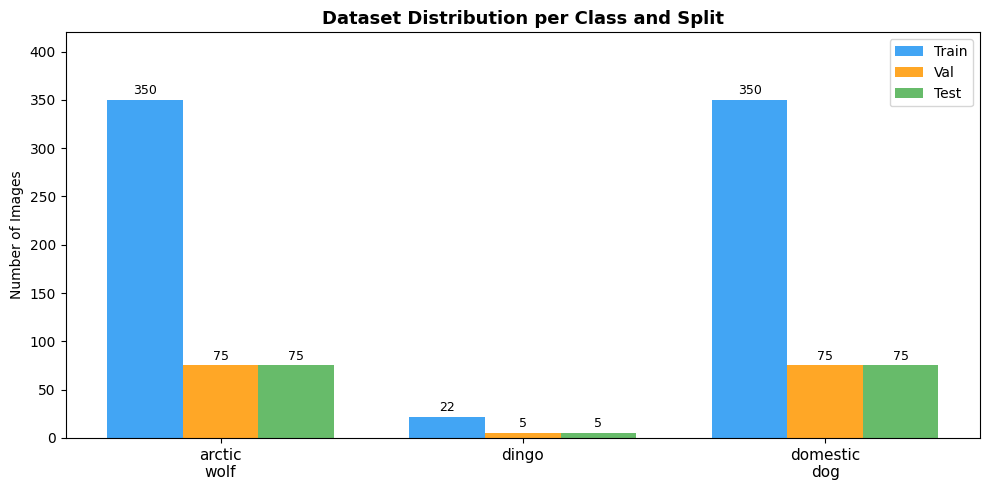

Saved: plot_dataset_distribution.png


In [3]:
splits = ["train", "val", "test"]
split_counts = {split: {} for split in splits}

for split in splits:
    for cls in CLASS_NAMES:
        cls_path = os.path.join(DATA_DIR, split, cls)
        if os.path.exists(cls_path):
            split_counts[split][cls] = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])
        else:
            split_counts[split][cls] = 0

# ---- Plot ----
x = np.arange(len(CLASS_NAMES))
width = 0.25
palette = ["#2196F3", "#FF9800", "#4CAF50"]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (split, colour) in enumerate(zip(splits, palette)):
    counts = [split_counts[split].get(c, 0) for c in CLASS_NAMES]
    bars = ax.bar(x + i * width, counts, width, label=split.capitalize(), color=colour, alpha=0.85)
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                str(val), ha="center", va="bottom", fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels([c.replace("_", "\n") for c in CLASS_NAMES], fontsize=11)
ax.set_ylabel("Number of Images")
ax.set_title("Dataset Distribution per Class and Split", fontsize=13, fontweight="bold")
ax.legend()
ax.set_ylim(0, max(max(v for v in split_counts[s].values()) for s in splits) * 1.2)
plt.tight_layout()
plt.savefig("plot_dataset_distribution.png", dpi=150)
plt.show()
print("Saved: plot_dataset_distribution.png")

**2. Sample Images per Class**

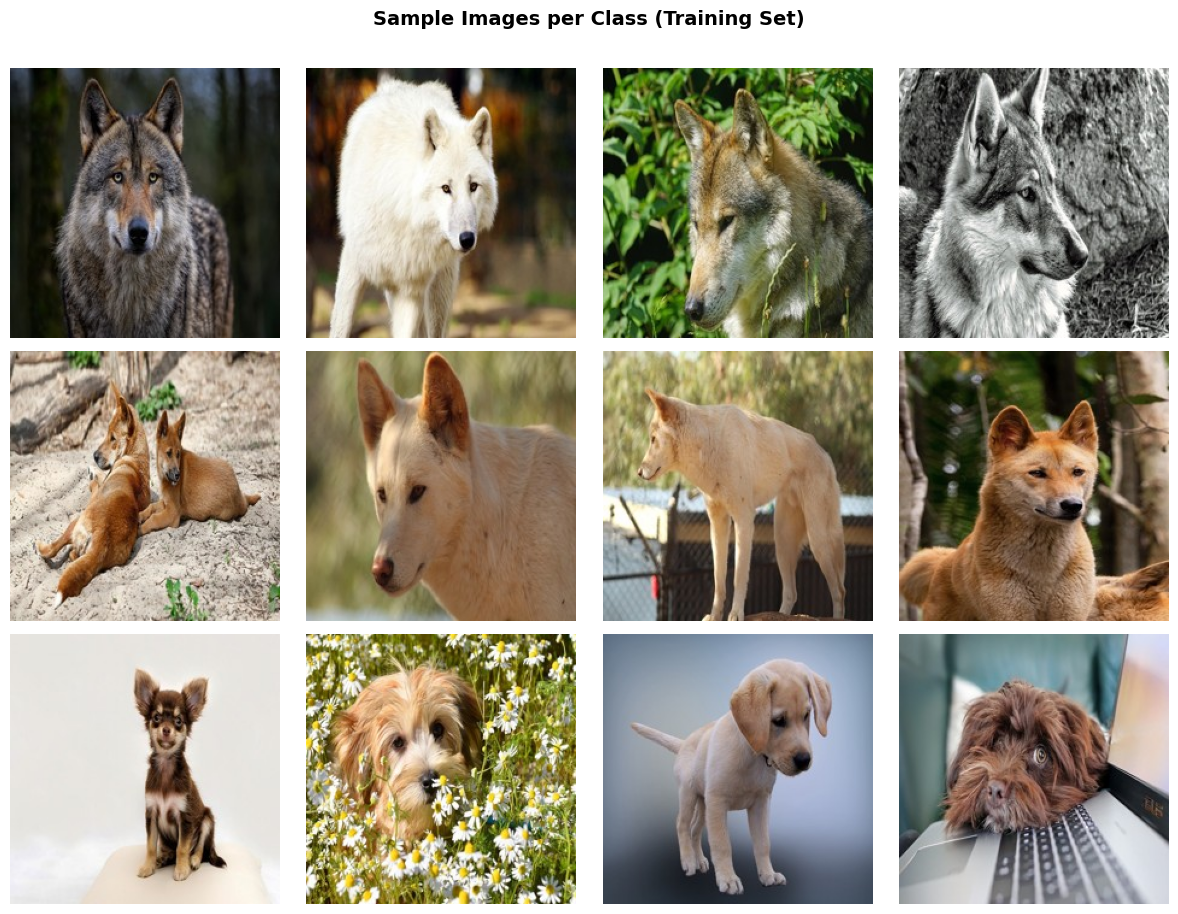

Saved: plot_sample_images.png


In [5]:
SAMPLES_PER_CLASS = 4
fig, axes = plt.subplots(len(CLASS_NAMES), SAMPLES_PER_CLASS,
                         figsize=(SAMPLES_PER_CLASS * 3, len(CLASS_NAMES) * 3))
fig.suptitle("Sample Images per Class (Training Set)", fontsize=14, fontweight="bold", y=1.01)

for row, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(DATA_DIR, "train", cls)
    all_imgs = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ] if os.path.exists(cls_path) else []
    sampled = random.sample(all_imgs, min(SAMPLES_PER_CLASS, len(all_imgs)))

    for col in range(SAMPLES_PER_CLASS):
        ax = axes[row][col]
        if col < len(sampled):
            img = Image.open(os.path.join(cls_path, sampled[col]))
            ax.imshow(img)
        else:
            ax.axis("off")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(cls.replace("_", "\n"), fontsize=10, rotation=0,
                          labelpad=60, va="center", fontweight="bold")

plt.tight_layout()
plt.savefig("plot_sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_sample_images.png")

**3.1 Model Accuracy Curves**

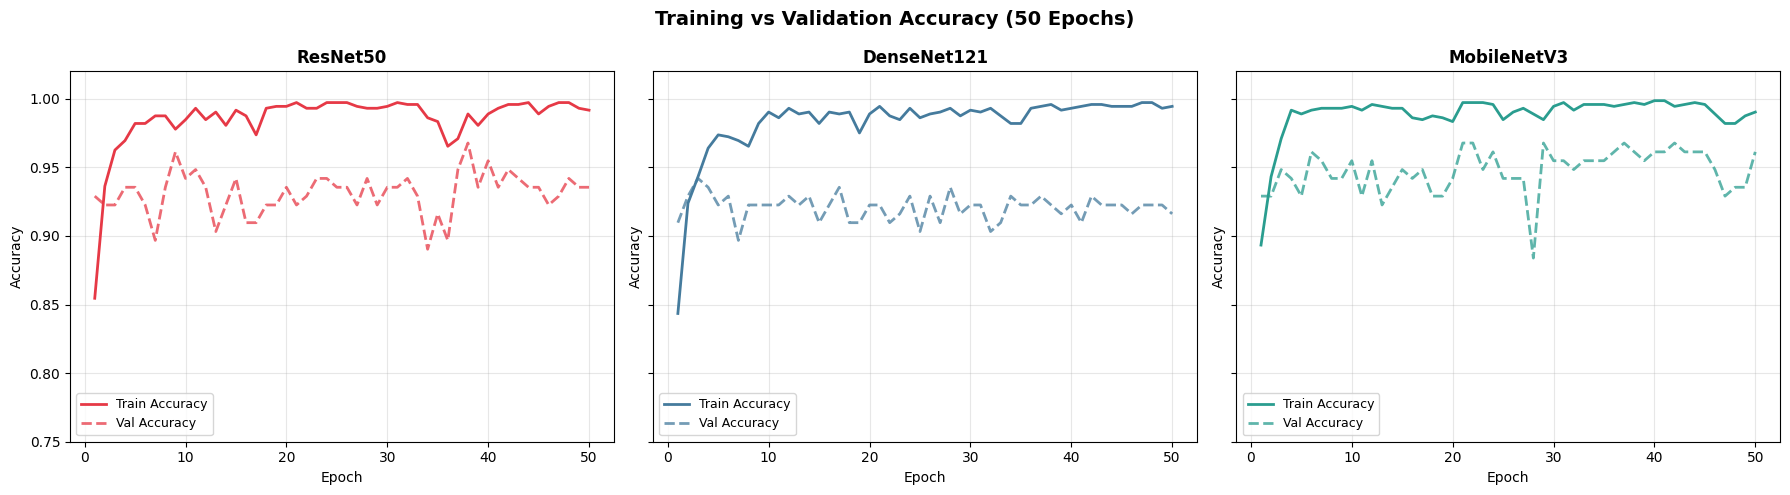

Saved: plot_accuracy_curves.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle("Training vs Validation Accuracy (50 Epochs)", fontsize=14, fontweight="bold")

for ax, model_name, colour in zip(axes, MODEL_NAMES, COLORS):
    h = history[model_name]
    epochs = range(1, len(h["accuracy"]) + 1)
    ax.plot(epochs, h["accuracy"],     color=colour,   lw=2,   label="Train Accuracy")
    ax.plot(epochs, h["val_accuracy"], color=colour,   lw=2,   label="Val Accuracy",
            linestyle="--", alpha=0.75)
    ax.set_title(model_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.75, 1.02)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot_accuracy_curves.png", dpi=150)
plt.show()
print("Saved: plot_accuracy_curves.png")

**3.2 Model Loss Curves**

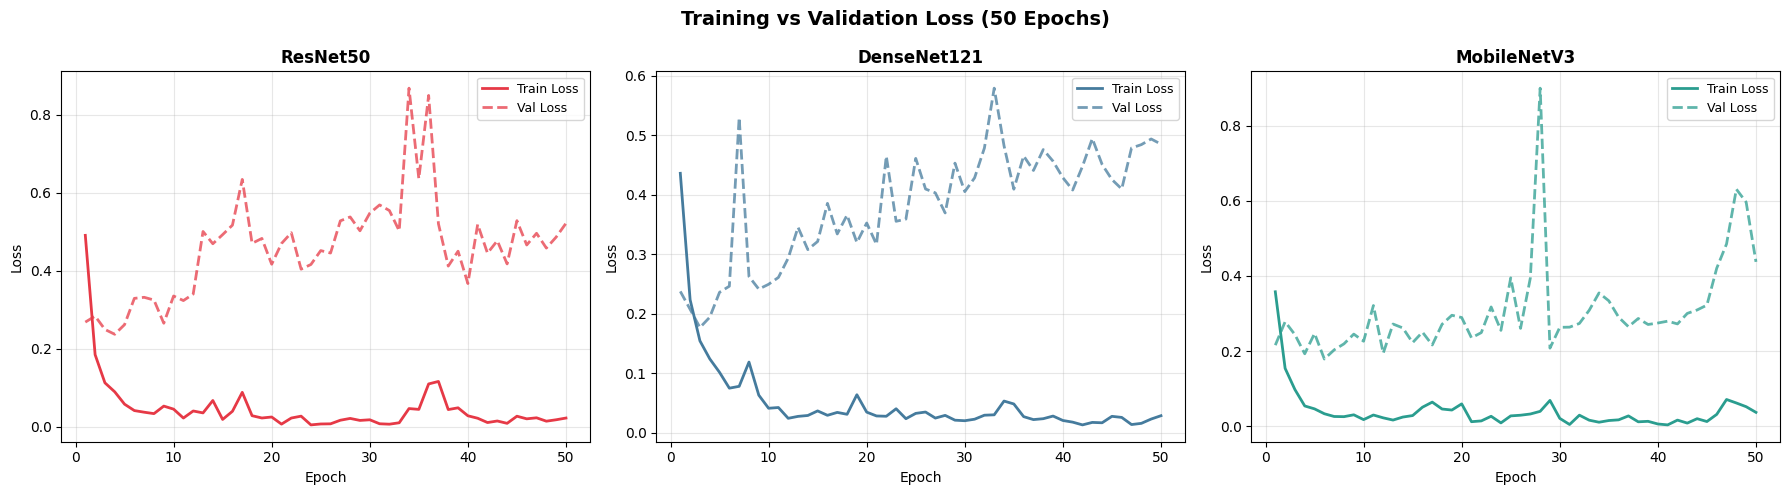

Saved: plot_loss_curves.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training vs Validation Loss (50 Epochs)", fontsize=14, fontweight="bold")

for ax, model_name, colour in zip(axes, MODEL_NAMES, COLORS):
    h = history[model_name]
    epochs = range(1, len(h["loss"]) + 1)
    ax.plot(epochs, h["loss"],     color=colour, lw=2,   label="Train Loss")
    ax.plot(epochs, h["val_loss"], color=colour, lw=2,   label="Val Loss",
            linestyle="--", alpha=0.75)
    ax.set_title(model_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot_loss_curves.png", dpi=150)
plt.show()
print("Saved: plot_loss_curves.png")

**Load Test Dataset**

In [15]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 8

# Load test dataset (no shuffle)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = test_ds.class_names
print("Test class names:", class_names)

# Ground truth labels
y_true = np.concatenate([np.argmax(labels.numpy(), axis=1) for _, labels in test_ds])
print(f"Total test samples: {len(y_true)}")

Found 155 files belonging to 3 classes.
Test class names: ['arctic_wolf', 'dingo', 'domestic_dog']
Total test samples: 155


**4. Confusion Matrix**


Loading ResNet50...

Loading DenseNet121...

Loading MobileNetV3...


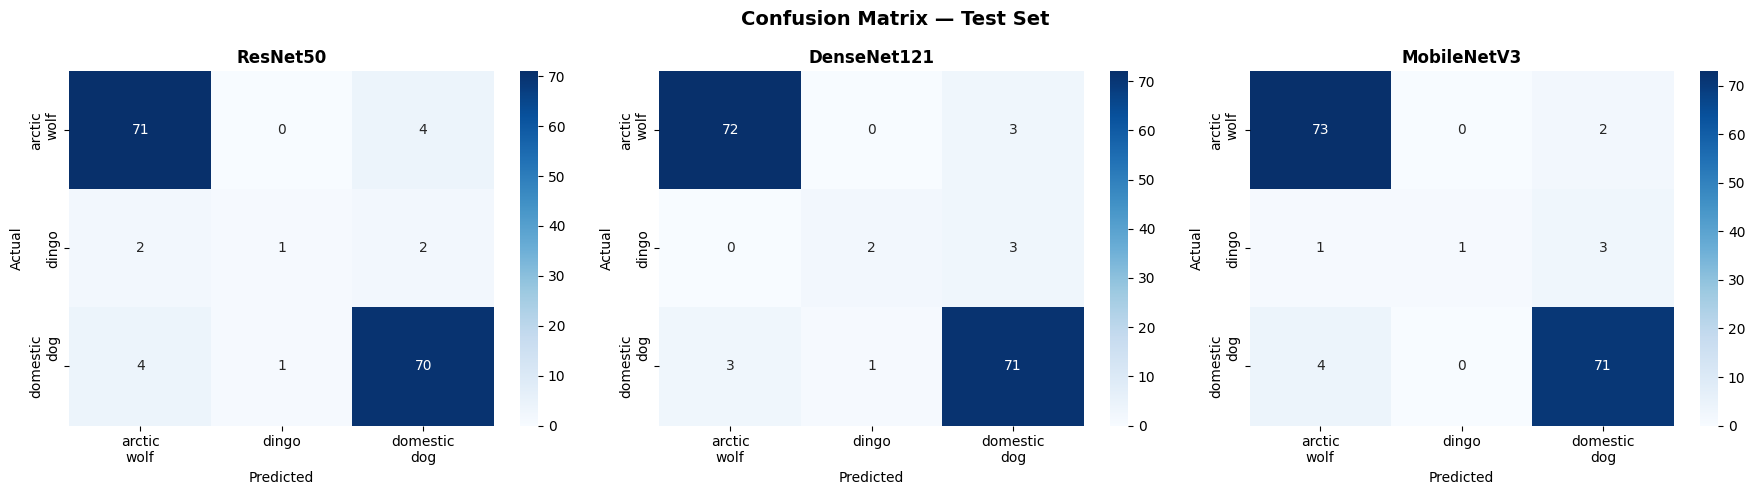

Saved: plot_confusion_matrices.png


In [14]:
from tensorflow.keras.applications.resnet50      import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet      import preprocess_input as dense_preprocess
from tensorflow.keras.applications.mobilenet_v3  import preprocess_input as mobile_preprocess

MODEL_FILES = {
    "ResNet50":    "ResNet50_canis_classifier.keras",
    "DenseNet121": "DenseNet121_canis_classifier.keras",
    "MobileNetV3": "MobileNetV3_canis_classifier.keras",
}

# Map model names to their respective preprocessing functions
PREPROCESS_FUNCTIONS = {
    "ResNet50": resnet_preprocess,
    "DenseNet121": dense_preprocess,
    "MobileNetV3": mobile_preprocess,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrix — Test Set", fontsize=14, fontweight="bold")

test_results = {}

for ax, (model_name, model_file) in zip(axes, MODEL_FILES.items()):
    print(f"\nLoading {model_name}...")
    # Provide the specific preprocess_input function as a custom object
    custom_objects = {"preprocess_input": PREPROCESS_FUNCTIONS[model_name]}
    model = load_model(model_file, custom_objects=custom_objects)

    y_pred_probs = model.predict(test_ds, verbose=0)
    y_pred       = np.argmax(y_pred_probs, axis=1)

    cm = confusion_matrix(y_true, y_pred)
    test_results[model_name] = {"y_pred": y_pred, "cm": cm}

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=[c.replace("_", "\n") for c in class_names],
        yticklabels=[c.replace("_", "\n") for c in class_names]
    )
    ax.set_title(model_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("plot_confusion_matrices.png", dpi=150)
plt.show()
print("Saved: plot_confusion_matrices.png")

**5. Validation mAP Curves**

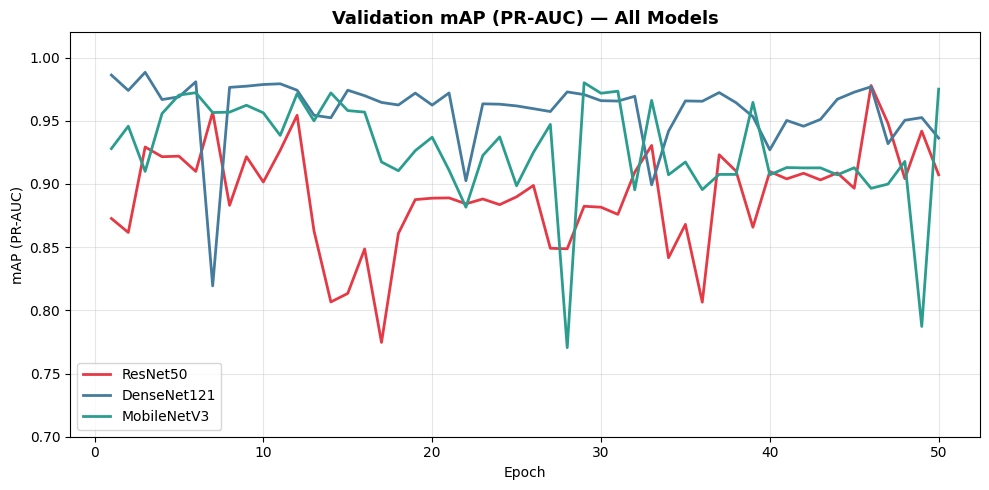

Saved: plot_val_map_curves.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

for model_name, colour in zip(MODEL_NAMES, COLORS):
    h = history[model_name]
    epochs = range(1, len(h["val_mAP"]) + 1)
    ax.plot(epochs, h["val_mAP"], color=colour, lw=2, label=model_name)

ax.set_title("Validation mAP (PR-AUC) — All Models", fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("mAP (PR-AUC)")
ax.set_ylim(0.7, 1.02)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot_val_map_curves.png", dpi=150)
plt.show()
print("Saved: plot_val_map_curves.png")

**6. Model Comparison Summary**

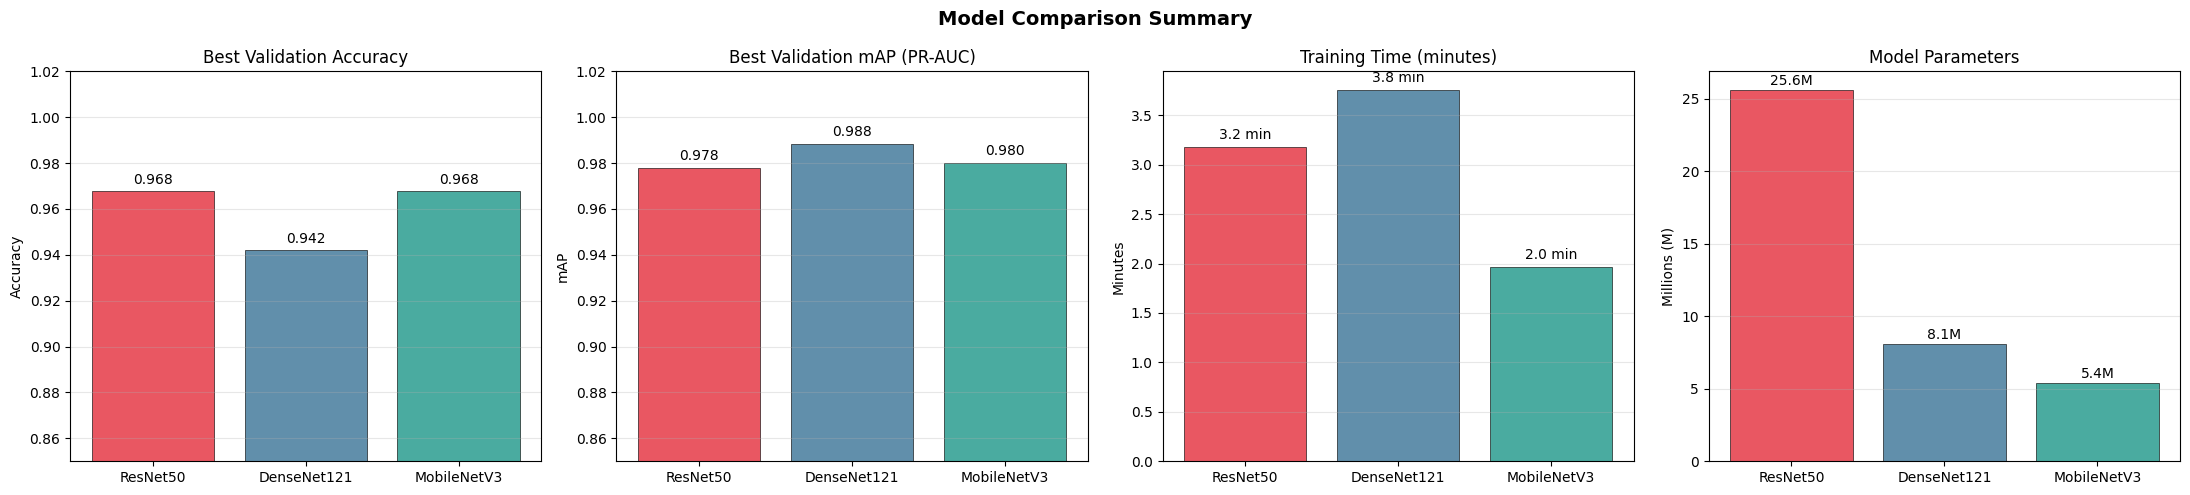

Saved: plot_model_comparison.png


In [16]:
# --- Summary metrics from training history ---
best_val_acc  = [max(history[m]["val_accuracy"]) for m in MODEL_NAMES]
best_val_map  = [max(history[m]["val_mAP"])      for m in MODEL_NAMES]
times_min     = [train_times[m] / 60             for m in MODEL_NAMES]
params_million = [25.6, 8.1, 5.4]  # ResNet50, DenseNet121, MobileNetV3 in millions

x = np.arange(len(MODEL_NAMES))
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Model Comparison Summary", fontsize=14, fontweight="bold")

# Val Accuracy
bars = axes[0].bar(MODEL_NAMES, best_val_acc, color=COLORS, alpha=0.85, edgecolor="black", lw=0.5)
for bar, val in zip(bars, best_val_acc):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=10)
axes[0].set_title("Best Validation Accuracy")
axes[0].set_ylim(0.85, 1.02)
axes[0].set_ylabel("Accuracy")

# Val mAP
bars = axes[1].bar(MODEL_NAMES, best_val_map, color=COLORS, alpha=0.85, edgecolor="black", lw=0.5)
for bar, val in zip(bars, best_val_map):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=10)
axes[1].set_title("Best Validation mAP (PR-AUC)")
axes[1].set_ylim(0.85, 1.02)
axes[1].set_ylabel("mAP")

# Training Time
bars = axes[2].bar(MODEL_NAMES, times_min, color=COLORS, alpha=0.85, edgecolor="black", lw=0.5)
for bar, val in zip(bars, times_min):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"{val:.1f} min", ha="center", va="bottom", fontsize=10)
axes[2].set_title("Training Time (minutes)")
axes[2].set_ylabel("Minutes")

# Parameters
bars = axes[3].bar(MODEL_NAMES, params_million, color=COLORS, alpha=0.85, edgecolor="black", lw=0.5)
for bar, val in zip(bars, params_million):
    axes[3].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"{val}M", ha="center", va="bottom", fontsize=10)
axes[3].set_title("Model Parameters")
axes[3].set_ylabel("Millions (M)")

for ax in axes:
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("plot_model_comparison.png", dpi=150)
plt.show()
print("Saved: plot_model_comparison.png")


## Final Conclusion

Three CNN models were trained and evaluated for the Canis subspecies classification task — ResNet50, DenseNet121, and MobileNetV3. Based on the results, each model performed differently across the four criteria.

ResNet50 achieved a validation accuracy of 96.8% but came with the highest parameter count at 25.6 million and a training time of around 3.2 minutes. While it performed well in accuracy, its size makes it less practical for deployment.

DenseNet121 recorded the highest mAP at 98.8%, meaning it had the best precision-recall balance across all three classes. However, it was the slowest model to train at 3.8 minutes, and its validation accuracy was slightly lower compared to the other two.

MobileNetV3 matched ResNet50 in validation accuracy at 96.8%, achieved a strong mAP of 98.0%, and completed training in just 2.0 minutes with only 5.4 million parameters. It delivered competitive results while being significantly lighter and faster than the other two models.

Overall, **MobileNetV3 is the most suitable model** for this classification task. It offers a good balance between accuracy, mAP, training efficiency, and model size. For a 3-class animal classification problem like this, there is no strong reason to use a heavier model when MobileNetV3 can achieve similar or better results at a fraction of the cost.

